In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

# Change the current working directory for the Python kernel
os.chdir('/content/drive/MyDrive/Academic content/UB 2026 Spring - Advanced Machine Learning/project')

# Verify the change
print(os.getcwd())


/content/drive/MyDrive/Academic content/UB 2026 Spring - Advanced Machine Learning/project


In [3]:
!ls -l

total 10538
-rw------- 1 root root  213084 Jan 23 00:13 'AML Example Project Report.pdf'
-rw------- 1 root root     896 Apr  1 06:41 'AML project on ALCF Polaris.txt'
-rw------- 1 root root 2378914 May  8 10:21 'AML project presentation (Physics-Informed Diffusion AI for MHD).pdf'
-rw------- 1 root root 2741311 May  8 10:22 'AML project presentation (Physics-Informed Diffusion AI for MHD).pptx'
-rw------- 1 root root  113156 Feb 14 06:06 'AML project proposal (Sarthak Sharma).pdf'
-rw------- 1 root root  148571 Mar 17 23:44 'CSE 674 (AML) project instructions.pdf'
-rw------- 1 root root     261 Mar 28 16:20 'inital training data.txt'
-rw------- 1 root root     709 Mar 27 00:44  inspect_MHD_data.py
-rw------- 1 root root    5165 Feb 14 06:07  main.tex
-rw------- 1 root root    1816 Mar 28 06:55  MHD_dataset.py
-rw------- 1 root root 1104849 Mar 28 06:24  mhd_results.png
-rw------- 1 root root   31433 Mar 28 14:25 'MSE and div B training plot.png'
-rw------- 1 root root   11625 Feb 14 06

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


In [5]:
def plot_training(df):
  n = len(df)
  fig, ax1 = plt.subplots() #figsize=(10, 6))

  # Plot MSE (Generative Loss)
  color = 'tab:blue'
  ax1.set_xlabel('Epoch', fontweight='bold') # , fontsize=12
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax1.set_ylabel('Mean Squared Error Loss (Generative)', color=color, fontweight='bold') # , fontsize=12
  ax1.plot(df['Epoch'], df['MSE'], color=color) #, marker='o', linewidth=2)
  ax1.tick_params(axis='y', labelcolor=color)
  ax1.set_ylim(bottom = 0)

  # Plot DivB (Physics Loss)
  ax2 = ax1.twinx()
  color = 'tab:red'
  ax2.set_ylabel('Div(B) Penalty (Physics Constraint)', color=color, fontweight='bold') # , fontsize=12
  ax2.plot(df['Epoch'], df['DivB'], color=color) #, marker='s', linewidth=2)
  ax2.tick_params(axis='y', labelcolor=color)

  # Title and Grid
  plt.title('Training the Diffusion AI Model \n on ALCF Polaris Supercomputer (eight A100 GPUs)') # , fontweight='bold', fontsize=14
  ax1.grid(True, linestyle='--', alpha=0.6)

  fig.tight_layout()
  plt.savefig('scale_presentation_plot_' + str(n) + '_epochs.png', bbox_inches = 'tight', dpi = 300)
  print("Saved scale_presentation_plot_" + str(n) + "_epochs.png successfully!")

In [6]:
# Read the newly generated CSV from the multi-node training
df_10 = pd.read_csv('training_log_10_epochs.csv')
df_10.columns = [col.strip() for col in df_10.columns] # Clean column names
print(df_10)

   Epoch       MSE        DivB
0      1  0.695178  124.131015
1      2  0.453801   12.234760
2      3  0.394265    7.292708
3      4  0.367845    4.409961
4      5  0.345625    3.622823
5      6  0.326072    4.250840
6      7  0.319778    2.356754
7      8  0.303416    1.552024
8      9  0.278628    1.423216
9     10  0.270172    1.310274


Saved scale_presentation_plot_10_epochs.png successfully!


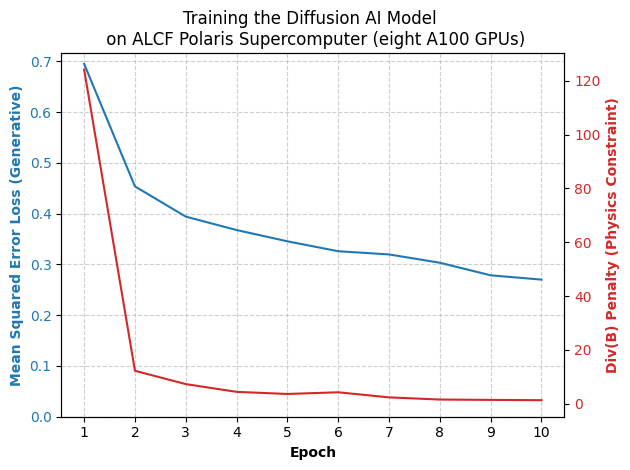

In [7]:
plot_training(df_10)

In [8]:
df_30_1 = pd.read_csv('training_log_30_epochs_1.csv')
df_30_1.columns = [col.strip() for col in df_30_1.columns] # Clean column names
print(df_30_1)

    Epoch       MSE        DivB
0       1  0.565530  130.587475
1       2  0.369720    9.257326
2       3  0.343680    4.072643
3       4  0.322282    2.608252
4       5  0.292356    1.792865
5       6  0.267977    1.302910
6       7  0.248923    0.896838
7       8  0.229850    0.778906
8       9  0.215240    0.586009
9      10  0.189259    0.589196
10     11  0.154931    0.437615
11     12  0.135214    0.357234
12     13  0.120124    0.327878
13     14  0.112361    0.211319
14     15  0.103616    0.185343
15     16  0.095415    0.154051
16     17  0.086996    0.165239
17     18  0.084034    0.181353
18     19  0.079841    0.069962
19     20  0.076605    0.151134
20     21  0.072046    0.056421
21     22  0.074015    0.103215
22     23  0.069573    0.057557
23     24  0.064408    0.087950
24     25  0.065080    0.083335
25     26  0.061384    0.050674
26     27  0.065827    0.097903
27     28  0.054224    0.028158
28     29  0.056289    0.037718
29     30  0.054854    0.034824


Saved scale_presentation_plot_30_epochs.png successfully!


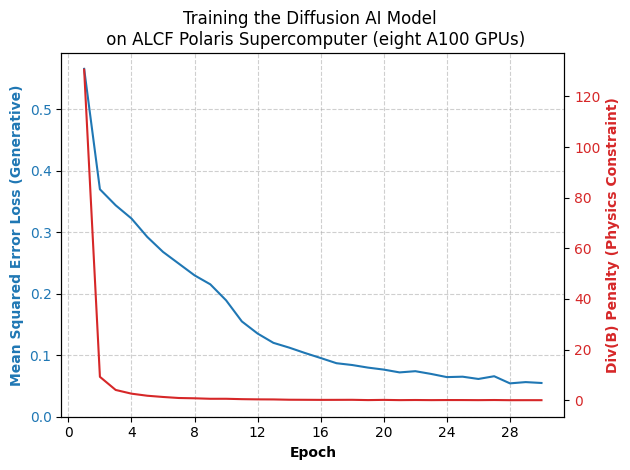

In [9]:
plot_training(df_30_1)

In [10]:
df_20 = pd.read_csv('training_log_20_epochs.csv')
df_20.columns = [col.strip() for col in df_20.columns] # Clean column names
print(df_20)

    Epoch       MSE        DivB
0       1  0.668929  124.673079
1       2  0.445731   11.748880
2       3  0.383963    9.403452
3       4  0.361105    5.671866
4       5  0.337963    3.895137
5       6  0.326554    2.596312
6       7  0.318823    2.168934
7       8  0.303177    1.473688
8       9  0.289192    4.000902
9      10  0.273063    1.491369
10     11  0.261135    0.726214
11     12  0.255751    0.987650
12     13  0.256007    0.735745
13     14  0.222789    0.721998
14     15  0.212811    0.735290
15     16  0.204987    0.644347
16     17  0.180463    0.449382
17     18  0.173690    0.465953
18     19  0.151335    0.416151
19     20  0.137555    0.353868


Saved scale_presentation_plot_20_epochs.png successfully!


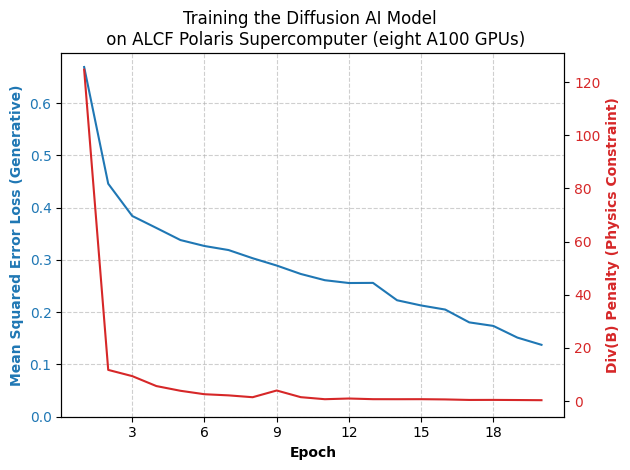

In [11]:
plot_training(df_20)

In [12]:
df_30_2 = pd.read_csv('training_log_30_epochs_2.csv')
df_30_2.columns = [col.strip() for col in df_30_2.columns] # Clean column names
print(df_30_2)

    Epoch       MSE        DivB
0       1  0.682722  194.729729
1       2  0.448122   11.427218
2       3  0.390925    8.114493
3       4  0.357314    4.924349
4       5  0.330943    4.214766
5       6  0.326909    2.380020
6       7  0.307450    2.048949
7       8  0.307869    1.760829
8       9  0.287297    1.277870
9      10  0.278463    1.336933
10     11  0.249505    1.185970
11     12  0.253290    0.847479
12     13  0.241457    0.847615
13     14  0.224468    1.022081
14     15  0.207762    0.613247
15     16  0.193679    0.410265
16     17  0.173016    0.445944
17     18  0.159835    0.464045
18     19  0.154748    0.372361
19     20  0.137720    0.354211
20     21  0.123638    0.373307
21     22  0.114832    0.241367
22     23  0.124872    0.225492
23     24  0.112836    0.180513
24     25  0.106946    0.194036
25     26  0.104932    0.185511
26     27  0.098802    0.134636
27     28  0.091656    0.150695
28     29  0.098268    0.284723
29     30  0.084800    0.093278


Saved scale_presentation_plot_30_epochs.png successfully!


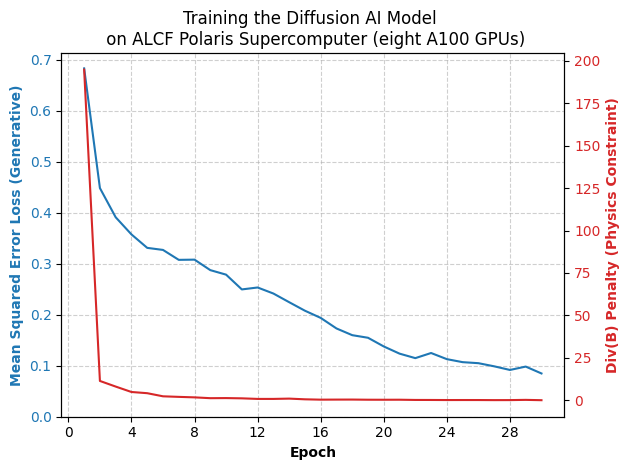

In [13]:
plot_training(df_30_2)